In [16]:
import cv2 as cv
import numpy as np
import easygui
import matplotlib.pyplot as plt

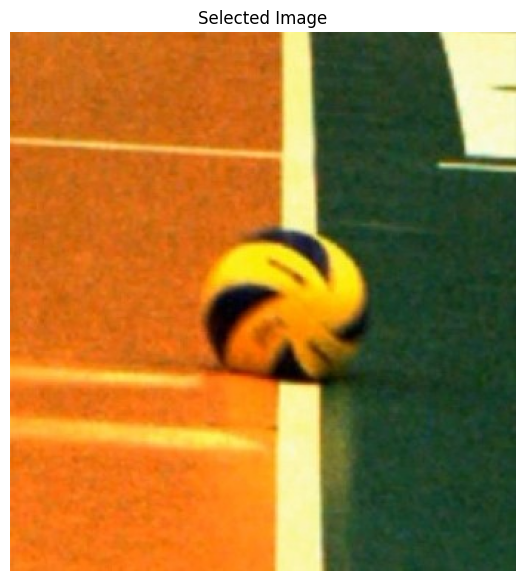

In [17]:
fp = easygui.fileopenbox()
img = cv.imread(fp)

plt.figure(figsize=(7, 7))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Selected Image")
plt.axis("off")
plt.show()

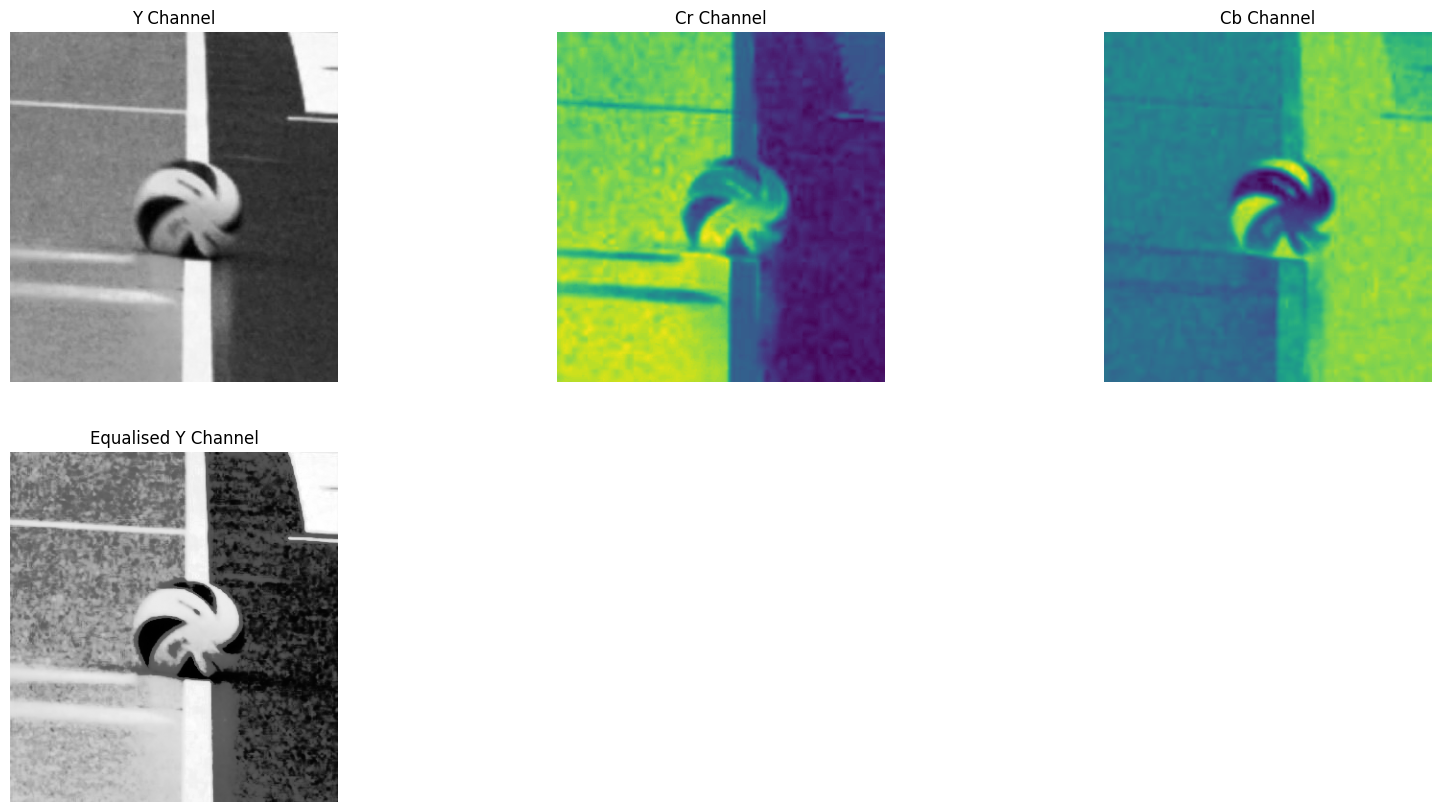

In [18]:
# Function to extract YCrCb channels and equalize the Y channel, displaying each step
def preprocess_channels(img):
    YCrCb = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv.split(YCrCb)
    equalised_y = cv.equalizeHist(Y)
    YCrCb_eq = cv.merge((equalised_y, Cr, Cb))
    
    plt.figure(figsize=(20,10))
    plt.subplot(2,3,1)
    plt.title('Y Channel')
    plt.imshow(Y, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2,3,2)
    plt.title('Cr Channel')
    plt.imshow(Cr)
    plt.axis('off')
    
    plt.subplot(2,3,3)
    plt.title('Cb Channel')
    plt.imshow(Cb)
    plt.axis('off')
    
    plt.subplot(2,3,4)
    plt.title('Equalised Y Channel')
    plt.imshow(equalised_y, cmap='gray')
    plt.axis('off')
    
    # plt.tight_layout()
    plt.show()
    return Y, Cr, Cb, equalised_y, YCrCb_eq

# Example usage:
Y, Cr, Cb, equalised_y, YCrCb_eq = preprocess_channels(img)

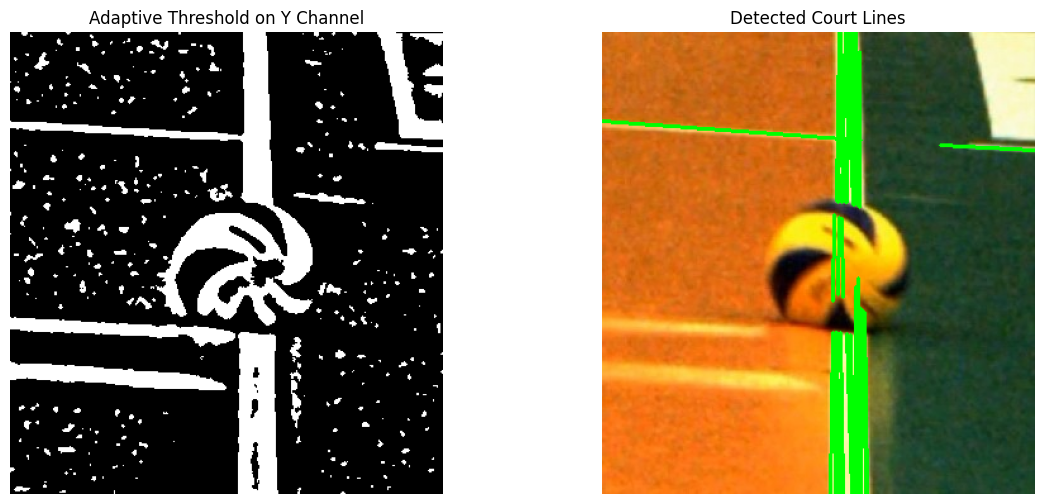

In [19]:
def detect_court_lines_with_preprocessing(img, Y):
    # Median blur, then adaptive threshold on the Y channel
    Y_blur = cv.medianBlur(Y, 3)
    adaptive_thresh = cv.adaptiveThreshold(Y_blur, 255,
                                           cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv.THRESH_BINARY, 49, -5)

    # Hough transform for court lines
    lines = cv.HoughLinesP(adaptive_thresh, 1, np.pi/180, 250, minLineLength=50, maxLineGap=10)

    # Draw lines on a copy of original image
    line_image = img.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv.line(line_image, (x1, y1), (x2, y2), (0,255,0), 2)

    # Display results
    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.title('Adaptive Threshold on Y Channel')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title('Detected Court Lines')
    plt.imshow(cv.cvtColor(line_image, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    return lines, adaptive_thresh, line_image

# Usage example (with your previous cell):
lines, adaptive_thresh, line_image = detect_court_lines_with_preprocessing(img, Y)

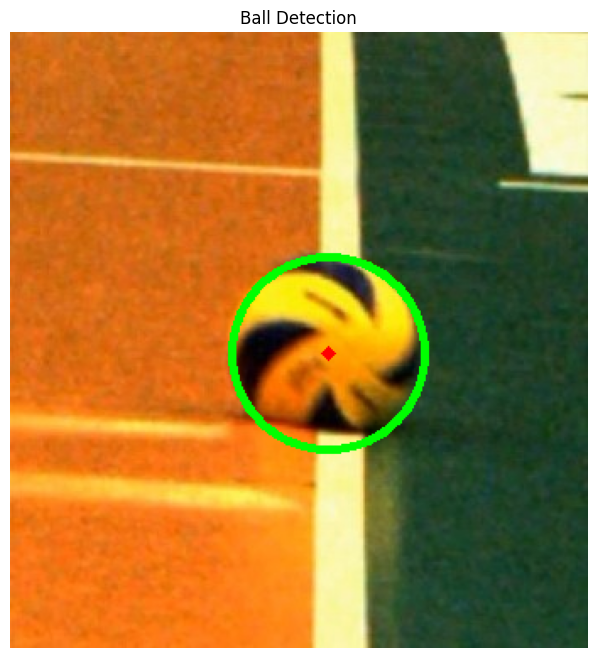

In [ ]:
def detect_ball(img):
    # Convert image to grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Apply a slight blur to reduce noise
    blurred = cv.medianBlur(gray, 5)

    # Try Hough Circle detection first
    circles = cv.HoughCircles(
        blurred,
        cv.HOUGH_GRADIENT,
        dp=1.2,
        minDist=40,
        param1=80,
        param2=15,
        minRadius=10,
        maxRadius=100
    )
    ball = None

    # If Hough Circles found, use the largest
    if circles is not None:
        circles = np.uint16(np.around(circles))
        main_circle = circles[0][0]
        center = (main_circle[0], main_circle[1])
        radius = main_circle[2]
        ball = {'type': 'circle', 'center': center, 'radius': radius}
    else:
        # Fallback to contour-based ellipse fitting
        _, thresh = cv.threshold(blurred, 60, 255, cv.THRESH_BINARY)
        contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

        max_area = 0
        best_contour = None
        for c in contours:
            area = cv.contourArea(c)
            perimeter = cv.arcLength(c, True)
            if perimeter == 0 or area < 200:
                continue
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            # Prioritize actual size for robustness
            if area > max_area and circularity > 0.72:
                max_area = area
                best_contour = c
        if best_contour is not None and len(best_contour) >= 5:
            ellipse = cv.fitEllipse(best_contour)
            ball = {'type': 'ellipse', 'ellipse': ellipse}

    # Draw results
    ball_img = img.copy()
    if ball is not None:
        if ball['type'] == 'circle':
            cv.circle(ball_img, ball['center'], ball['radius'], (0, 255, 0), 3)
            cv.circle(ball_img, ball['center'], 2, (0, 0, 255), 3)
        elif ball['type'] == 'ellipse':
            cv.ellipse(ball_img, ball['ellipse'], (0, 255, 0), 3)
            
    plt.figure(figsize=(8,8))
    plt.imshow(cv.cvtColor(ball_img, cv.COLOR_BGR2RGB))
    plt.title("Ball Detection")
    plt.axis('off')
    plt.show()

    return ball

# Usage:
ball = detect_ball(img)


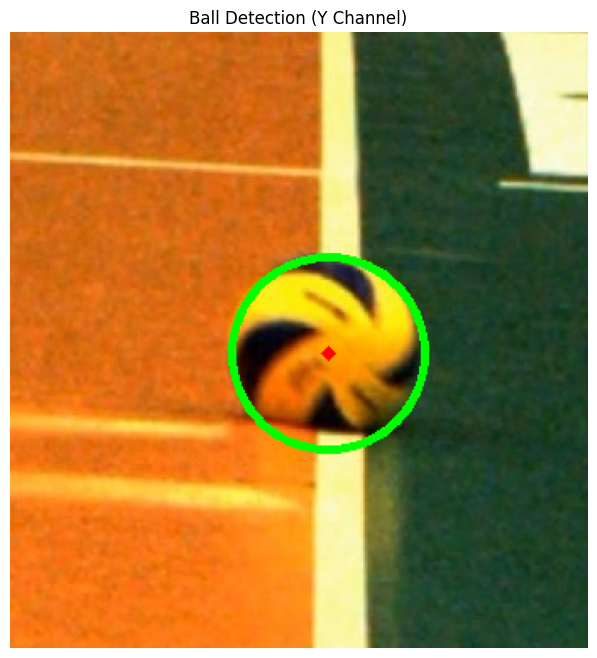

In [ ]:
def detect_ball_from_y(img, Y):
    # Use the already-preprocessed Y channel, and apply a blur to reduce noise
    blurred = cv.medianBlur(Y, 5)

    # Try Hough Circle detection first
    circles = cv.HoughCircles(
        blurred,
        cv.HOUGH_GRADIENT,
        dp=1.2,
        minDist=40,
        param1=80,
        param2=15,
        minRadius=10,
        maxRadius=100
    )
    ball = None

    if circles is not None:
        circles = np.uint16(np.around(circles))
        main_circle = circles[0][0]
        center = (main_circle[0], main_circle[1])
        radius = main_circle[2]
        ball = {'type': 'circle', 'center': center, 'radius': radius}
    else:
        # If no circle, fallback to contour-based ellipse
        _, thresh = cv.threshold(blurred, 60, 255, cv.THRESH_BINARY)
        contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

        max_area = 0
        best_contour = None
        for c in contours:
            area = cv.contourArea(c)
            perimeter = cv.arcLength(c, True)
            if perimeter == 0 or area < 200:
                continue
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            if area > max_area and circularity > 0.72:
                max_area = area
                best_contour = c
        if best_contour is not None and len(best_contour) >= 5:
            ellipse = cv.fitEllipse(best_contour)
            ball = {'type': 'ellipse', 'ellipse': ellipse}

    # Draw results
    ball_img = img.copy()
    if ball is not None:
        if ball['type'] == 'circle':
            cv.circle(ball_img, ball['center'], ball['radius'], (0, 255, 0), 3)
            cv.circle(ball_img, ball['center'], 2, (0, 0, 255), 3)
        elif ball['type'] == 'ellipse':
            cv.ellipse(ball_img, ball['ellipse'], (0, 255, 0), 3)
            
    plt.figure(figsize=(8,8))
    plt.imshow(cv.cvtColor(ball_img, cv.COLOR_BGR2RGB))
    plt.title("Ball Detection (Y Channel)")
    plt.axis('off')
    plt.show()

    return ball

# Usage:
ball = detect_ball_from_y(img, Y)


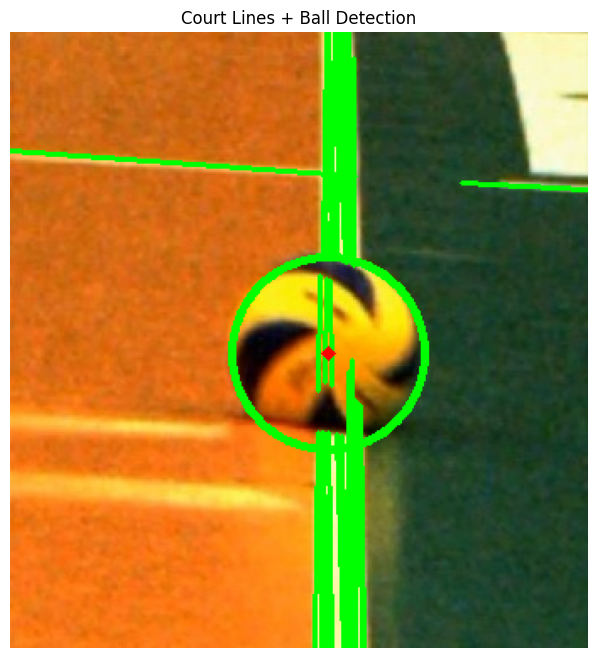

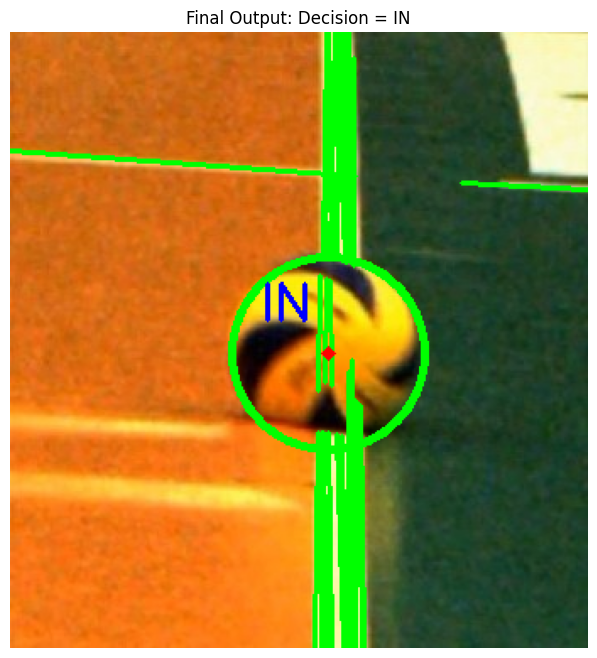

In [ ]:
def decision_in_out(ball, lines, img):
    # Start with the original image
    combined_img = img.copy()

    # Overlay court lines
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv.line(combined_img, (x1, y1), (x2, y2), (0,255,0), 2)
            
    # Overlay ball detection
    if ball is not None:
        if ball['type'] == 'circle':
            cv.circle(combined_img, ball['center'], ball['radius'], (0, 255, 0), 3)
            cv.circle(combined_img, ball['center'], 2, (0, 0, 255), 3)
        elif ball['type'] == 'ellipse':
            cv.ellipse(combined_img, ball['ellipse'], (0, 255, 0), 3)

    # Show image with both overlays
    plt.figure(figsize=(8,8))
    plt.imshow(cv.cvtColor(combined_img, cv.COLOR_BGR2RGB))
    plt.title("Court Lines + Ball Detection")
    plt.axis('off')
    plt.show()

    # Now add the in/out decision for final annotated output
    result_img = combined_img.copy()
    decision = "Unknown"

    if ball is not None and lines is not None:
        if ball['type'] == 'circle':
            ball_center_x, ball_center_y = ball['center']
            ball_radius = ball['radius']
        elif ball['type'] == 'ellipse':
            ellipse = ball['ellipse']
            ball_center_x, ball_center_y = int(ellipse[0][0]), int(ellipse[0][1])
            ball_radius = int((ellipse[1][0] + ellipse[1][1]) / 4)
        min_dist, line_x = float('inf'), None

        for line in lines:
            x1, y1, x2, y2 = line[0]
            if abs(x1 - x2) < 10:
                dist = abs(ball_center_x - x1)
                if dist < min_dist:
                    min_dist, line_x = dist, x1
                    
        if line_x is not None:
            decision = "IN" if abs(ball_center_x - line_x) < ball_radius else "OUT"
        cv.putText(result_img, decision, (ball_center_x - 40, ball_center_y - 20),
                   cv.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    # Show final image with decision
    plt.figure(figsize=(8,8))
    plt.imshow(cv.cvtColor(result_img, cv.COLOR_BGR2RGB))
    plt.title(f"Final Output: Decision = {decision}")
    plt.axis('off')
    plt.show()

    return decision

# Usage:
decision = decision_in_out(ball, lines, img)
